In [1]:
#Import required libraries for data handling, numerical analysis, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the three cleaned datasets from Milestone 1 preprocessing
demographics = pd.read_csv("demographics_clean.csv")
social = pd.read_csv("social_clean.csv")
transactions = pd.read_csv("transactions_clean.csv")
# Preview the Demographics dataset to confirm it loaded correctly
demographics.head()

,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate
0,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17
1,5fb09cd8-a473-46f7-80bd-6e49cf509078,NaN,Female,Castilloport,High,2020-07-21
2,c139496e-cc89-498a-bd90-1fb4627b6cff,37.0,Male,Lake Jennifertown,NaN,2021-01-01
3,50118139-7264-428f-81cc-a25fddc5d6dd,44.0,Male,Port Carl,Medium,2024-10-06
4,7d1f2bbc-8d16-4fbc-9b37-ece3324e8ed4,50.0,Female,Jessebury,High,2023-08-24


In [2]:
# Additional NumPy statistical computations for Age
print("Age - Mean:", np.mean(demographics["Age"].dropna()))
print("Age - Median:", np.median(demographics["Age"].dropna()))
print("Age - Standard Deviation:", np.std(demographics["Age"].dropna(), ddof=1))
print("Age - Variance:", np.var(demographics["Age"].dropna(), ddof=1))
print("Age - Minimum:", np.min(demographics["Age"].dropna()))
print("Age - Maximum:", np.max(demographics["Age"].dropna()))
print("Age - Range:", np.max(demographics["Age"].dropna()) - np.min(demographics["Age"].dropna()))
print("Age - IQR:", np.percentile(demographics["Age"].dropna(), 75) - np.percentile(demographics["Age"].dropna(), 25))

Age - Mean: 45.42167342425359
Age - Median: 45.0
Age - Standard Deviation: 19.731359576533006
Age - Variance: 389.3265507384407
Age - Minimum: -1.0
Age - Maximum: 150.0
Age - Range: 151.0
Age - IQR: 27.0


In [3]:
# Additional NumPy statistical computations for Transaction Amount
print("Amount_Clean - Mean:", np.mean(transactions["Amount_Clean"].dropna()))
print("Amount_Clean - Median:", np.median(transactions["Amount_Clean"].dropna()))
print("Amount_Clean - Standard Deviation:", np.std(transactions["Amount_Clean"].dropna(), ddof=1))
print("Amount_Clean - Variance:", np.var(transactions["Amount_Clean"].dropna(), ddof=1))
print("Amount_Clean - Minimum:", np.min(transactions["Amount_Clean"].dropna()))
print("Amount_Clean - Maximum:", np.max(transactions["Amount_Clean"].dropna()))
print("Amount_Clean - Range:", np.max(transactions["Amount_Clean"].dropna()) - np.min(transactions["Amount_Clean"].dropna()))
print("Amount_Clean - IQR:", np.percentile(transactions["Amount_Clean"].dropna(), 75) - np.percentile(transactions["Amount_Clean"].dropna(), 25))
print("Amounts at or below zero:", (transactions["Amount_Clean"].dropna() <= 0).sum())

Amount_Clean - Mean: 489.788919319023
Amount_Clean - Median: 496.625
Amount_Clean - Standard Deviation: 299.2394527529937
Amount_Clean - Variance: 89544.25008391115
Amount_Clean - Minimum: -100.0
Amount_Clean - Maximum: 999.86
Amount_Clean - Range: 1099.8600000000001
Amount_Clean - IQR: 518.4575
Amounts at or below zero: 70


In [4]:
#  Calculate the 25th, 50th (median), and 75th percentiles of Age
#  This shows how customer ages are spread out, separate from the extreme Age anomalies (-1, 150)

age_percentiles = np.percentile(demographics["Age"].dropna(), [25, 50, 75])
print("25th, 50th, 75th percentiles of Age:", age_percentiles)

25th, 50th, 75th percentiles of Age: [31. 45. 58.]


In [5]:
#  Calculate the 25th, 50th (median), and 75th percentiles of Transaction Amount
#  This shows how transaction values are spread out, separate from the extreme anomalies (<= 0)

amount_percentiles = np.percentile(transactions["Amount_Clean"].dropna(), [25, 50, 75])
print("25th, 50th, 75th percentiles of Transaction Amount:", amount_percentiles)

25th, 50th, 75th percentiles of Transaction Amount: [228.24   496.625  746.6975]


In [6]:
sentiment_counts = social["Sentiment"].value_counts()
print(sentiment_counts)

Positive         905
Neutral          874
Negative         866
Unknown          309
Very Negative     34
Very Positive     32
Name: Sentiment, dtype: int64


### Identifying Variables for Visualization

Based on the Milestone 1 EDA findings, the following variables and observations were identified as important for visualization:

 **Age (Demographics):** Contains 63 anomalous values (below 0 or above 100, including -1 and 150) that could not be clearly seen in raw statistics alone a histogram would visually reveal where these anomalies cluster.

 **Transaction Amount (Transactions):** Contains anomalous negative values, including a recurring -100, which represent a significant portion of the data  a histogram and box plot would show how these compare to the overall spread.

 **Sentiment (Social Media):** Shows a clear class imbalance (Very Negative: 34, Very Positive: 32 vs. 800-900 for other categories) that is easier to communicate visually through a bar/count plot than through raw numbers.
 
 **Age vs. Transaction Amount relationship:** The calculated correlation (0.021) suggested little to no relationship, which is best confirmed visually through a scatter plot and correlation heatmap.

We prioritized these variables because they are directly tied to the anomalies, imbalances, and relationships identified during Milestone 1 (EDA), and visualizing them makes these findings clearer and easier to explain to FinMark Corporation's broader team.

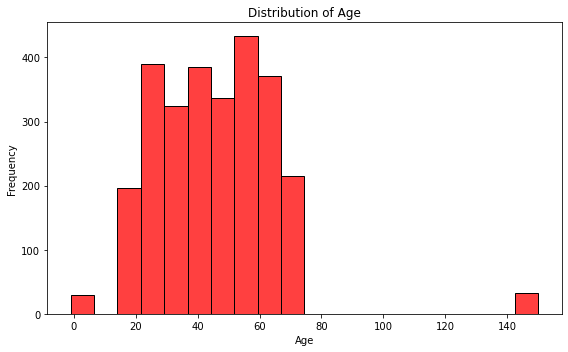

In [7]:
# Visualize the distribution of Age, including the anomalous values (-1 and 150)
plt.figure(figsize=(8,5))
sns.histplot(demographics["Age"].dropna(), bins=20, color="red")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Most of FinMark's customers fall between roughly 15 and 75 years old, representing the realistic range of their customer base. However, two small clusters sit well outside this range near 0 (the -1 anomaly) and near 150, suggesting potential data-quality issues. The 63 previously identified Age anomalies should be verified against the dataset to confirm their distribution. For FinMark's future machine learning activities, such as customer segmentation by age group, these unusual values should be investigated and corrected or removed if appropriate, since they could distort age-based groupings and lead to inaccurate customer profiles.

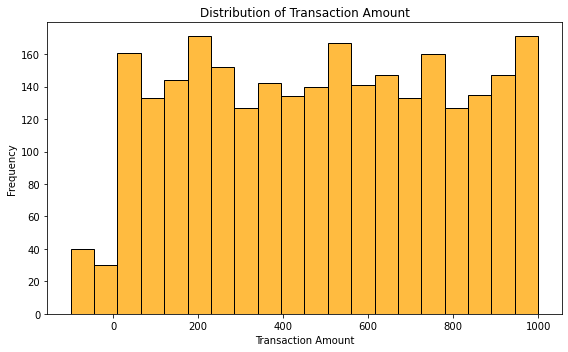

In [8]:
# Visualize the distribution of Transaction Amount, including anomalies (negative/zero values)
plt.figure(figsize=(8,5))
sns.histplot(transactions["Amount_Clean"].dropna(), bins=20, color="orange")
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Transaction amounts are spread fairly evenly between 0 and 1000, with a smaller but distinct cluster of negative values (including the recurring -100). These negative values may represent refunds, reversals, data-entry errors, or other transaction types and should be investigated before being used in financial modeling. The 70 records with amounts at or below zero should be reviewed to determine whether these values are valid and how they should be handled in future analysis.

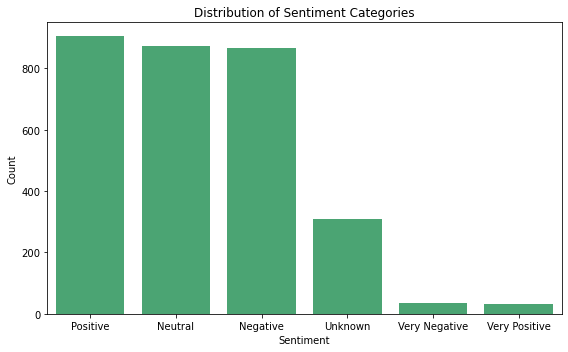

In [9]:
# Visualize the distribution of Sentiment categories, showing the class imbalance
plt.figure(figsize=(8,5))
sns.countplot(data=social, x="Sentiment", order=social["Sentiment"].value_counts().index, color="mediumseagreen")
plt.title("Distribution of Sentiment Categories")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation:** Positive, Neutral, and Negative sentiments are fairly balanced (approximately 866–905 each). The "Unknown" category (309 records, approximately 10% of the dataset) is the fourth-largest bar in the chart, but it does not represent a genuine sentiment; it reflects interactions where Sentiment was missing in the original data and was imputed as "Unknown" during Week 3 preprocessing, so it should be separated from the five genuine sentiment classes. Among the real sentiment classes, Very Negative and Very Positive are dramatically smaller (32–34 each) than Positive, Neutral, and Negative, indicating a significant class imbalance. This may affect how well a future sentiment classification model learns the less common classes. The "Unknown" records should be reviewed to determine whether they are suitable for the intended analysis, and the model's performance across the different sentiment classes should be evaluated carefully.

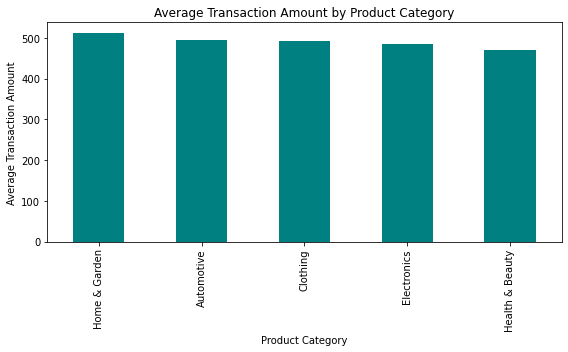

In [10]:
# Compare average Transaction Amount across different Product Categories
avg_amount_by_category = transactions.groupby("ProductCategory")["Amount_Clean"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_amount_by_category.plot(kind="bar", color="teal")
plt.title("Average Transaction Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Amount")
plt.tight_layout()
plt.show()

**Interpretation:** Average transaction amounts across the five product categories are fairly close to each other, ranging from about 470 (Health & Beauty) to about 510 (Home & Garden), a difference of only about 40 units. Unlike the Sentiment categories, which showed a clear imbalance, no single product category stands out as dominating customer spending based on average transaction value. For FinMark Corporation, this suggests that ProductCategory alone may not fully explain differences in transaction amounts. However, similar average values do not necessarily mean that ProductCategory is not useful for prediction. Further analysis using other variables, such as PaymentMethod or customer demographics, may help explain spending behavior.

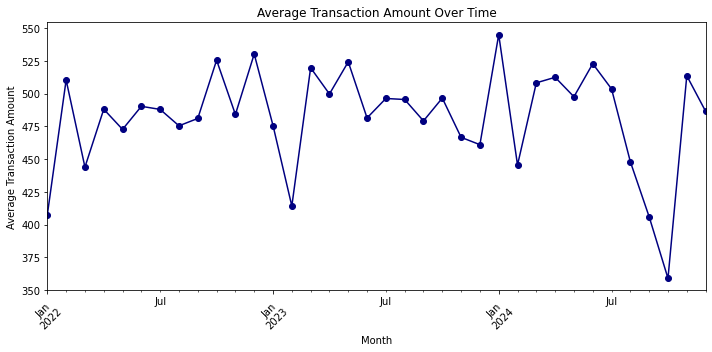

In [11]:
# Convert TransactionDate to a proper date type
transactions["TransactionDate"] = pd.to_datetime(transactions["TransactionDate"], errors="coerce")

# Group by month and calculate the average Transaction Amount
monthly_avg_amount = transactions.groupby(transactions["TransactionDate"].dt.to_period("M"))["Amount_Clean"].mean()

# Line chart showing average Transaction Amount trend over time
plt.figure(figsize=(10,5))
monthly_avg_amount.plot(kind="line", marker="o", color="navy")
plt.title("Average Transaction Amount Over Time")
plt.xlabel("Month")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** The average transaction amount fluctuates month to month between roughly 360 and 550, without showing a clear long-term upward or downward trend. Spending levels appear relatively stable overall, with normal variation. A few points stand out, however: there is a noticeable dip around mid-2022, a sharper dip in mid-2023, and another sharp dip in mid-2024 (down to about 360, the lowest point in the dataset), as well as a sharp spike around January 2024 (up to about 545). These fluctuations may warrant further investigation to understand whether they are related to seasonal customer behavior, data quality issues, or specific business events. The chart alone cannot determine the causes of these changes.

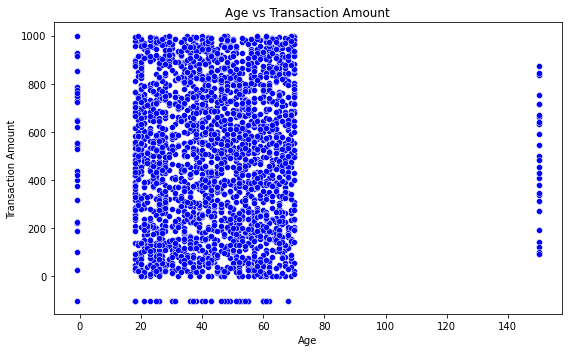

In [12]:
# Merge Demographics and Transactions on CustomerID to compare Age and Transaction Amount
age_amount = pd.merge(demographics[["CustomerID", "Age"]], transactions[["CustomerID", "Amount_Clean"]], on="CustomerID", how="inner")
age_amount = age_amount.dropna(subset=["Age", "Amount_Clean"])

# Visualize the relationship between Age and Transaction Amount
plt.figure(figsize=(8,5))
sns.scatterplot(data=age_amount, x="Age", y="Amount_Clean", color="blue")
plt.title("Age vs Transaction Amount")
plt.xlabel("Age")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

**Interpretation:**  The data points form a wide, scattered cloud with no clear visible upward or downward trend, consistent with the near-zero correlation (0.021) calculated earlier. This suggests that Age has little linear relationship with transaction amount in this dataset. However, this does not necessarily mean Age has no predictive value, since other types of relationships may exist. For FinMark Corporation, future modeling efforts should consider other variables as well and evaluate their usefulness using appropriate model testing.

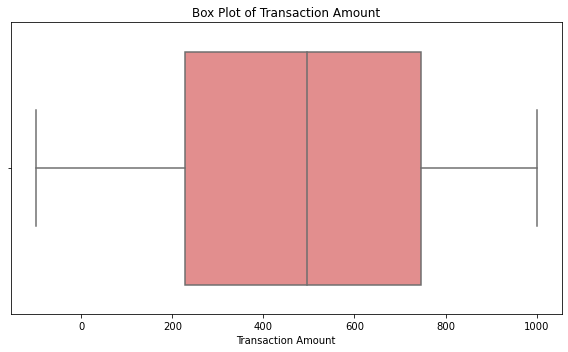

In [13]:
# Box plot of Transaction Amount to visually highlight outliers/anomalies
plt.figure(figsize=(8,5))

sns.boxplot(x=transactions["Amount_Clean"], color="lightcoral")
plt.title("Box Plot of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.tight_layout()
plt.show()

**Interpretation:**  Interestingly, the box plot's standard outlier detection did not flag the negative transaction values as statistical outliers, since the overall data spread is wide enough to include them within the whisker range. This highlights an important consideration for future preprocessing: statistical outlier methods alone aren't sufficient here. Domain knowledge is necessary to identify potential data-quality issues that purely statistical methods might miss. Since negative transaction amounts can represent refunds or reversals rather than errors, these values should be investigated to determine their meaning before deciding how to handle them.

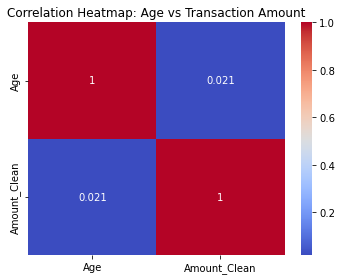

In [14]:
# Correlation heatmap between Age and Transaction Amount
plt.figure(figsize=(5,4))
correlation_matrix = age_amount[["Age", "Amount_Clean"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap: Age vs Transaction Amount")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap visually reinforces the scatter plot's finding that Age and Transaction Amount share a correlation of just 0.021, indicating essentially no linear relationship between a customer's age and how much they spend. For FinMark Corporation, this suggests that Age alone may have limited value for predicting transaction amounts using a linear relationship. However, this does not necessarily mean Age would be useless in every machine learning model. Additional variables, such as Platform usage, Sentiment, or ProductCategory, could also be explored to better understand or predict transaction behavior.

## Summary of Visualization Findings

The visualizations in this notebook extend the Milestone 1 EDA by confirming, and in some cases sharpening, the data-quality and relationship findings identified earlier. The Age and Transaction Amount distributions contain unusual values at the extremes that require further investigation. The Sentiment chart shows that the genuine sentiment classes are imbalanced, particularly because the "Very Negative" and "Very Positive" categories contain far fewer records than the Positive, Neutral, and Negative categories. The "Unknown" records should be considered separately because they represent missing sentiment information that was imputed during preprocessing.

Average transaction amounts are relatively similar across product categories, while monthly spending fluctuates over time without a clear long-term upward or downward trend. The near-zero Age–Amount correlation of approximately 0.021 is visually supported by both the scatter plot and the correlation heatmap. The box plot also illustrates that statistical outlier detection may not identify every value that deserves investigation, including the negative transaction amounts.

Together, these findings reinforce the importance of combining statistical analysis with domain knowledge to investigate potential data-quality issues before using the data in future machine learning models. Further analysis is needed to determine how unusual transaction values should be handled and which variables are most useful for predicting customer behavior.